# Multi-Layer Perceptron in Tensorflow

Multi-layer perception is fully a connected dense network with multiple layers, which transform any input dimension to the desired dimension. To create a neural network we combine neurons together so that the outputs of some neurons are inputs of other neurons.

Every node in the multi-layer perception uses a sigmoid activation function. The sigmoid activation function takes real values as input and converts them to numbers between 0 and 1 using the sigmoid formula.

![image.png](attachment:image.png)


The above network has three inputs and thus three input nodes and one hidden layer with three nodes. The output layer gives two outputs, therefore there are two output nodes.

### This notebook presents a multi-layer perceptron in case of binary classification using sigmoid activation

## Stepwise Implementation:


### 1. Import the necessary libraries

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Activation
import matplotlib.pyplot as plt
import tensorflow as tf

### 2. Load the MNIST dataset from keras library

TensorFlow allows us to read the MNIST dataset and we can load it directly in the program as a train and test dataset.

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 3. Convert the pixels into floating-point values

The pixel values range from 0 to 256, apart from 0 the range is 255. Dividing all the values by 255 to convert the range from 0 to 1.

Converting the pixel values into floating-point values helps in computation becomes easier and faster.


In [ ]:
# Cast the records into float values
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

# normalize image pixel values by dividing
# by 255
gray_scale = 255
x_train /= gray_scale
x_test /= gray_scale

### 4. Prepare the binary dataset for classification

In [ ]:
# For binary classification, we'll limit the dataset to digits '0' and '1'
binary_train_mask = np.isin(y_train, [0, 1])
binary_test_mask = np.isin(y_test, [0, 1])

x_train_binary = x_train[binary_train_mask]
y_train_binary = y_train[binary_train_mask]

x_test_binary = x_test[binary_test_mask]
y_test_binary = y_test[binary_test_mask]

# Reshape labels to make it binary (0 and 1)
y_train_binary = np.where(y_train_binary == 1, 1, 0)
y_test_binary = np.where(y_test_binary == 1, 1, 0)

In [ ]:
print("Training data:", x_train_binary.shape)
print("Test data:", x_test_binary.shape)
print("Training label data:", y_train_binary.shape)
print("Test label data:", y_test_binary.shape)

Training data: (12665, 28, 28)
Test data: (2115, 28, 28)
Training label data: (12665,)
Test label data: (2115,)


### 5. Visualize the data

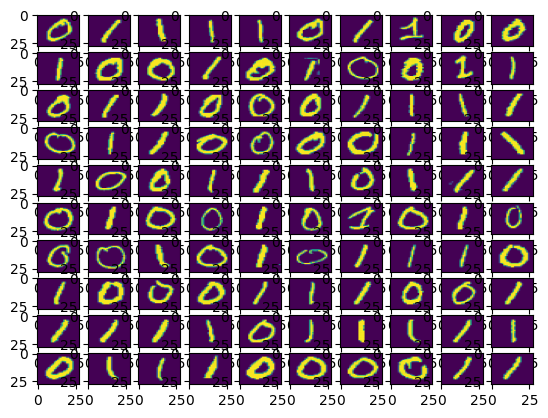

In [ ]:
fig, ax = plt.subplots(10, 10)
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train_binary[k].reshape(28, 28),
                        aspect='auto')
        k += 1
plt.show()

### 6. Define the network

In [ ]:
model = Sequential([

    # reshape 28 row * 28 column data to 28*28 rows
    Flatten(input_shape=(28, 28)),

      # hidden dense layer 1
    Dense(128, activation='relu', name='L1'),

    # hidden dense layer 2
    Dense(64, activation='relu', name='L2'),

      # output layer
    Dense(1, activation='sigmoid', name='L3'),   ## prefer sigmoid activation for binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


The Sequential model creates the model layer-by-layer as needed in a multi-layer perceptron, with a sigmoid activation function at each of the layers.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L1 (Dense)                      │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

#### Get the weights and bias for each layer

In [ ]:
W1, b1 = model.get_layer("L1").get_weights()
W2, b2 = model.get_layer("L2").get_weights()
W3, b3 = model.get_layer("L3").get_weights()

print(f"W1{W1.shape}:\n", W1, f"\nb1{b1.shape}:", b1)
print(f"W2{W2.shape}:\n", W2, f"\nb2{b2.shape}:", b2)
print(f"W3{W3.shape}:\n", W3, f"\nb3{b3.shape}:", b3)

W1(784, 128):
 [[ 0.01715036 -0.02932547 -0.05934375 ... -0.06409627  0.01465669
   0.05251091]
 [-0.00138574  0.04605182  0.03750211 ...  0.07904059 -0.06584438
  -0.07495856]
 [ 0.05640895  0.03071013  0.0226892  ... -0.0352368   0.02571296
  -0.02299034]
 ...
 [ 0.00383568 -0.00352767 -0.01399577 ...  0.01898913  0.05522471
   0.06391945]
 [-0.03536165  0.04173461 -0.01771342 ...  0.01106267  0.06226294
   0.02560505]
 [-0.00268792  0.00714138  0.00916199 ... -0.06709504  0.05108265
   0.02747512]] 
b1(128,): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]
W2(128, 64):
 [[ 0.04757634 -0.01041651  0.03748849 ... -0.08158167  0.01281513
   0.131783

### 7. Compile the model

The model.compile statement defines a loss function and specifies a compile optimization.


In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

### 8. Fit the model

The model.fit statement runs gradient descent and fits the weights to the data.

In [ ]:
history= model.fit(x_train_binary, y_train_binary, epochs=10, batch_size=32, validation_data=(x_test_binary, y_test_binary))

Epoch 1/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9965 - loss: 0.0145 - val_accuracy: 0.9991 - val_loss: 0.0024
Epoch 2/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9991 - loss: 0.0022 - val_accuracy: 0.9995 - val_loss: 0.0030
Epoch 3/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9976 - val_loss: 0.0047
Epoch 4/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9995 - loss: 0.0016 - val_accuracy: 0.9991 - val_loss: 0.0018
Epoch 5/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9999 - loss: 2.3124e-04 - val_accuracy: 0.9991 - val_loss: 0.0018
Epoch 6/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9998 - loss: 7.8097e-04 - val_accuracy: 0.9995 - val_loss: 0.0029
Epoch 7/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 1.0000 - loss: 5.7348e-05 - val_accuracy: 0.9995 - val_loss: 0.0023
Epoch 8/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 2.5722e-05 - 

In [ ]:
# Examine the change in weights and biases at each layer
W1, b1 = model.get_layer("L1").get_weights()
W2, b2 = model.get_layer("L2").get_weights()
W3, b3 = model.get_layer("L3").get_weights()

print(f"W1{W1.shape}:\n", W1, f"\nb1{b1.shape}:", b1)
print(f"W2{W2.shape}:\n", W2, f"\nb2{b2.shape}:", b2)
print(f"W3{W3.shape}:\n", W3, f"\nb3{b3.shape}:", b3)

W1(784, 128):
 [[ 0.01715036 -0.02932547 -0.05934375 ... -0.06409627  0.01465669
   0.05251091]
 [-0.00138574  0.04605182  0.03750211 ...  0.07904059 -0.06584438
  -0.07495856]
 [ 0.05640895  0.03071013  0.0226892  ... -0.0352368   0.02571296
  -0.02299034]
 ...
 [ 0.00383568 -0.00352767 -0.01399577 ...  0.01898913  0.05522471
   0.06391945]
 [-0.03536165  0.04173461 -0.01771342 ...  0.01106267  0.06226294
   0.02560505]
 [-0.00268792  0.00714138  0.00916199 ... -0.06709504  0.05108265
   0.02747512]] 
b1(128,): [-0.00958366  0.04355209  0.0358279  -0.03728223  0.002012   -0.01965965
 -0.02504424 -0.01231414 -0.0316419  -0.02398152 -0.01344075  0.00735023
 -0.01832128 -0.017909    0.0347128  -0.01180696 -0.01197994 -0.02378712
 -0.03511364 -0.01250454 -0.00972304  0.03724335 -0.00789767  0.0486673
 -0.03420305 -0.01830435  0.05393357 -0.01169907 -0.00504062 -0.00962527
 -0.00696343  0.0627408  -0.00457774 -0.00777513 -0.0123243  -0.01329052
  0.02050474  0.03865052 -0.00544423  0.00808

### 9. Find Accuracy and loss for the model

In [ ]:
test_loss, test_acc = model.evaluate(x_test_binary,  y_test_binary, verbose = 1)
print('test loss, test acc:', test_loss, test_acc)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9995 - loss: 0.0023    
test loss, test acc: 0.0023227203637361526 0.9995272159576416


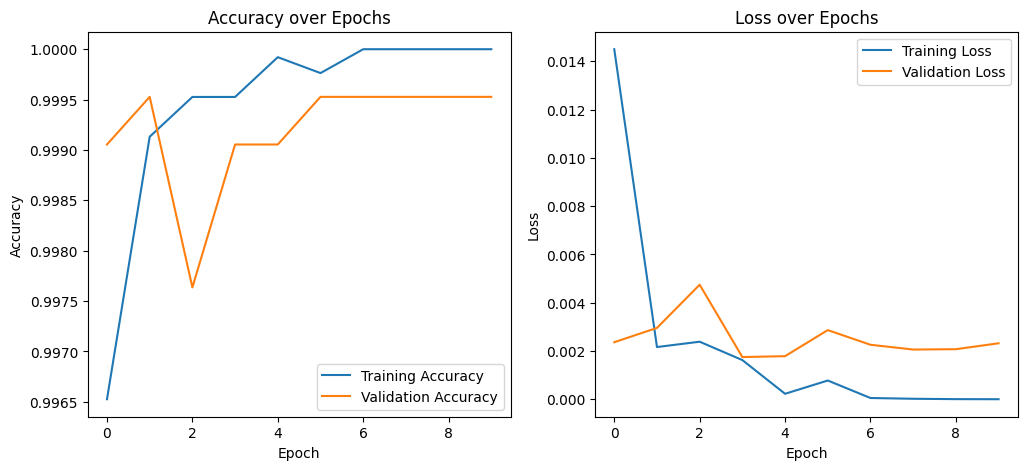

In [ ]:
# Plot accuracy
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### 10. Evalaute other performance metrics

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Predict class probabilities for the test data
y_pred_probs = model.predict(x_test_binary)

# Convert predicted probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate Precision, Recall, and F1-score
precision = precision_score(y_test_binary, y_pred, average='macro')
recall = recall_score(y_test_binary, y_pred, average='macro')
f1 = f1_score(y_test_binary, y_pred, average='macro')

# Print the metrics
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Precision: 0.23167848699763594
Recall: 0.5
F1 Score: 0.3166397415185784


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
